In [1]:
import torch
import pprint
lam_path: str = "/mnt/mnt/public/chenjl/code/UniVLA/latent_action_model/logs/vjepa_lam/epoch=14-step=20000.ckpt"

In [2]:
lam_ckpt = torch.load(lam_path, map_location="cpu")['state_dict']

for k, v in lam_ckpt.items():
    print(k)


/tmp/ipykernel_3083509/917989657.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lam_ckpt = torch.load(lam_path, map_location="cpu")['state_dict']

KeyboardInterrupt



In [ ]:
import tensorflow

2025-09-19 13:18:11.903219: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-19 13:18:11.941236: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-19 13:18:11.941273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-19 13:18:11.942145: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-19 13:18:11.947699: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
print(tensorflow.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
!export HF_HOME="/mnt/public_zgc/home/jlchen/.cache/huggingface"
!export HF_HUB_CACHE="/mnt/public_zgc/home/jlchen/.cache/huggingface/models"
!export HF_DATASETS_CACHE="/mnt/public_zgc/home/jlchen/.cache/huggingface/datasets"
from transformers import AutoVideoProcessor, AutoModel

hf_repo = "facebook/vjepa2-vith-fpc64-256"

model = AutoModel.from_pretrained(hf_repo, force_download=True)
processor = AutoVideoProcessor.from_pretrained(hf_repo)


2025-09-22 12:46:04.810409: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 12:46:05.340166: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-22 12:46:05.340226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-22 12:46:05.404927: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-22 12:46:05.566404: I tensorflow/core/platform/cpu_feature_guar

ValueError: Force download failed due to the above error.

In [ ]:
import json
import os
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Optional, Tuple, Union, Dict, Any
from datetime import datetime

import torch
import torch.distributed as dist
import yaml
from latent_action_model.core.lam_model import load_latent_action_model
from prismatic.overwatch import initialize_overwatch
from prismatic.util import set_global_seed
from prismatic.vla import get_latent_vla_dataset_and_collator
from prismatic.vla.datasets.datasets import RLDSDataset
from prismatic.models import load_InternVL,freeze_internvl
from prismatic.vla.datasets.rlds.utils.data_utils import save_dataset_statistics
from typing import cast
from prismatic.training.accelerate_fsdp_trainer import run_latent_action_training
from transformers import AutoProcessor

# Sane Defaults
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


# Initialize Overwatch =>> Wraps `logging.Logger`
overwatch = initialize_overwatch(__name__)

# 📝 动作 token 列表: ['<ACT_0>', '<ACT_1>', '<ACT_2>', '<ACT_3>', '<ACT_4>', '<ACT_5>', '<ACT_6>', '<ACT_7>', '<ACT_8>', '<ACT_9>', '<ACT_10>', '<ACT_11>', '<ACT_12>', '<ACT_13>', '<ACT_14>', '<ACT_15>']
# 🔢 对应的 token ID: [151679, 151680, 151681, 151682, 151683, 151684, 151685, 151686, 151687, 151688, 151689, 151690, 151691, 151692, 151693, 151694]
# 🎯 action_token_begin_id = 151679
# 📊 ID 范围: 151679 - 151694

@dataclass
class TrainConfig:
    # fmt: off

    # =========================
    # 路径与资源
    # =========================
    # Directory Paths
    data_root_dir: Path = Path("/mnt/mnt/public/jlchen/datasets")
    run_root_dir: Path =  Path("vla_log")    # Store logs & checkpoints under vla_scripts/

    # Hugging Face 模型标识（或本地权重目录）；用于 PrismaticVLM.from_pretrained()
    model_id: str = '/mnt/mnt/public/jlchen/code/UniVLA/vla_scripts/vla_log/1106_150243+nsvq_bridgensvq_bridge/checkpoints/checkpoint-8000'
    hf_cache_dir: Optional[Path] = None
    lam_ckpt_path: str = "/mnt/mnt/public/jlchen/code/UniVLA/latent_action_model/logs/jepa_bridge_noar_noposnos_vq/version_0/checkpoints/epoch=19.ckpt"
    lam_yaml_path: str = "/mnt/mnt/public/jlchen/code/UniVLA/latent_action_model/logs/jepa_bridge_noar_noposnos_vq/version_0/jepa_bridge.yaml"
    # =========================
    # 数据与预处理
    # =========================
    # 数据混合与缓冲
    data_mix: str = "bridge_dataset"
    shuffle_buffer_size: int = 20_00
    image_resolution: int = 448
    image_aug: bool = True                                          # Whether to enable image augmentations

    # =========================
    # 模型冻结策略
    # =========================
    # 冻结策略
    freeze_vision_backbone: bool = False
    freeze_llm_backbone: bool = False
    freeze_last_llm_layer: bool = False
    freeze_projector: bool = False

    # =========================
    # LAM / 动作离散参数
    # =========================
    action_token_begin_id: int = 151679
    # VJEPA_LAM 模型架构参数
    vision_model_id: str = "/mnt/mnt/public/jlchen/weights/vjepa2-vitl-fpc64-256"
    codebook_size: int = 16  #此处修改无效，仅作为标记
    # =========================
    # 训练设置
    # =========================
    # 训练超参
    epochs: Optional[int] = 10
    max_steps: Optional[int] = 20000  #以max_steps为准，若为空则按epochs * 10000近似
    per_device_batch_size: int = 4
    gradient_accumulation_steps: int = 1
    learning_rate: float = 2e-3
    warmup_steps: int = 1000
    weight_decay: float = 0.0
    max_grad_norm: float = 1.0
    lr_scheduler_type: str = "constant"   #constant_with_warmup
    # 训练加速
    enable_mixed_precision_training: bool = True
    seed: int = 42                                                  # Random seed (for reproducibility)

    # =========================
    # 评估与保存
    # =========================
    eval_strategy: str = "steps"
    save_total_limit: int = -1
    eval_interval: int = 4
    eval_accumulation_steps: int = 1
    per_device_eval_batch_size: int = 128
    save_interval: int = 1000                                    # Interval for saving checkpoints (in steps

    # =========================
    # 分布式 / FSDP
    # =========================
    fsdp: Optional[str] = "full_shard"                     # 示例："full_shard auto_wrap" 或 None 关闭
    fsdp_config: Optional[Dict[str, Any]] = None   # 示例：{"fsdp_min_num_params": 1e7, "xla": False}

    # =========================
    # 运行与日志
    # =========================
    # Run Arguments
    run_id: Optional[str] =  None                                  # Run ID for logging, Weights & Biases
    run_id_note: Optional[str] = "run_01"                               # Extra note for logging, Weights & Biases
    # Tracking Parameters
    wandb_project: str = "vla_pretraining"                   # Name of W&B project to log to (use default!)
    # wandb_entity: str = "opendrivelab"                              # Name of entity to log under

    # =========================
    # 恢复 / 断点（仅用于日志标记，不再用于模型权重加载）
    # =========================
    # Resume (logging) Parameters -- 仅用于日志标记，不再用于模型权重加载
    resume_step: Optional[int] = None
    resume_epoch: Optional[int] = None

    # =========================
    # HF Hub 凭据（如有门限模型）
    # =========================
    # HF Hub Credentials (for any gated models)
    hf_token: Optional[str] = None

    # fmt: on

cfg=TrainConfig

overwatch.info("OpenVLA Training :: Warming Up")

# Note => Under `torchrun` initializing `overwatch` will automatically set up `torch.distributed`
torch.cuda.set_device(device_id := overwatch.local_rank())
torch.cuda.empty_cache()

# Configure Unique Run Name & Save Directory
vla_tag = f"{cfg.model_id.split('/')[-1]}+{cfg.data_mix}"
world_size = overwatch.world_size() if dist.is_initialized() else max(torch.cuda.device_count(), 1)
overwatch.info(f"Detected world_size = {world_size}")
cfg.run_id = (
    f"{vla_tag}+n{world_size}+b{cfg.per_device_batch_size}+x{cfg.seed}"
    if cfg.run_id is None
    else cfg.run_id
)
if cfg.run_id_note is not None:
    cfg.run_id += f"--{cfg.run_id_note}"
if cfg.image_aug:
    cfg.run_id += "--image_aug"

# cfg.run_id += '-Latent-Action-Pretraining'
# Start =>> Build Directories and Set Randomness
overwatch.info('"Do or do not; there is no try."', ctx_level=1)
# hf_token = cfg.hf_token.read_text().strip() if isinstance(cfg.hf_token, Path) else os.environ[cfg.hf_token]
hf_token = str(cfg.hf_token) if isinstance(cfg.hf_token, Path) else cfg.hf_token
worker_init_fn = set_global_seed(cfg.seed, get_worker_init_fn=True)
# 统一时间戳并广播，确保所有进程共用同一目录
if dist.is_initialized():
    if overwatch.is_rank_zero():
        ts: Optional[str] = datetime.now().strftime("%m%d_%H%M%S")
    else:
        ts = None
    obj_list = [ts]
    dist.broadcast_object_list(obj_list, src=0)
    timestamp = obj_list[0]
    assert isinstance(timestamp, str)
else:
    timestamp = datetime.now().strftime("%m%d_%H%M%S")

run_dir_name = f"{timestamp}+{cfg.run_id}"
run_dir = (cfg.run_root_dir / run_dir_name)
# 仅 rank0 创建目录，其余进程等待

if dist.is_initialized():
    dist.barrier()

# os.makedirs(cfg.run_root_dir / cfg.run_id / "checkpoints", exist_ok=True)



# 直接通过 HF ID/Path 加载 InternVL 模型与处理器
overwatch.info(f"🔄 加载基础 InternVL `{cfg.model_id}`（HF from_pretrained）")
vlm, processor = load_InternVL(cfg.model_id, cfg.hf_cache_dir, dtype=torch.bfloat16) 
tokenizer = processor.tokenizer
vlm.generation_config.max_new_tokens = int(getattr(cfg, "max_new_tokens", 4))
vlm.config.loss_type = str(getattr(cfg, "loss_type", "ForCausalLMLoss"))
vlm.config.use_cache = False

# 直接按配置冻结模块（若可用）；HF-only InternVL 组件名：vision_tower / language_model / multi_modal_projector / lm_head
freeze_internvl(vlm, cfg.freeze_vision_backbone, cfg.freeze_projector, cfg.freeze_llm_backbone, cfg.freeze_last_llm_layer)
overwatch.info("🔧 扩充 LLM 词表以注入动作离散 token")
special_tokens_dict = {'additional_special_tokens': [f'<ACT_{i}>' for i in range(cfg.codebook_size)]}
try:
    num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)  # type: ignore[attr-defined]
    overwatch.info(f"num_added_toks={num_added_toks}")
except Exception:
    num_added_toks = 0

# Print number of total/trainable model parameters
num_params = sum(p.numel() for p in vlm.parameters())
num_trainable_params = sum(p.numel() for p in vlm.parameters() if p.requires_grad)
overwatch.info(
    f"# Parameters (in millions): {num_params / 10**6:.3f} Total, {num_trainable_params / 10**6:.3f} Trainable"
)

# Get VLA Dataset & Collator

overwatch.info(
    f"🔄 加载 V-JEPA2 动作编码器与码本（ckpt=`{cfg.lam_ckpt_path}`，"
    f"K={cfg.codebook_size}）"
)
latent_action_model = load_latent_action_model(cfg.lam_ckpt_path, cfg.lam_yaml_path)  # default freeze all parameters
latent_action_model = latent_action_model.to(device_id).eval()
overwatch.info(
    f"🔄 构建 RLDS 数据集与 Collator（mixture=`{cfg.data_mix}`，image_res={cfg.image_resolution}）"
)
# 类型提示规避：latent_action_tokenizer 需要 VQ 编码器，这里用 cast 静态规避
train_dataset, val_dataset, collator = get_latent_vla_dataset_and_collator(
    cfg.data_root_dir,
    cfg.data_mix,
    latent_action_model,
    processor=processor,
    default_image_resolution=cfg.image_resolution,
    shuffle_buffer_size=cfg.shuffle_buffer_size,
    image_aug=cfg.image_aug,
)
print(latent_action_model.device)
   

[*] OpenVLA Training :: Warming Up
[*] Detected world_size = 2
    |=> "Do or do not; there is no try."
[*] 🔄 加载基础 InternVL `/mnt/mnt/public/jlchen/code/UniVLA/vla_scripts/vla_log/1106_150243+nsvq_bridgensvq_bridge/checkpoints/checkpoint-8000`（HF from_pretrained）
[*] 🔧 扩充 LLM 词表以注入动作离散 token
[*] num_added_toks=0
[*] # Parameters (in millions): 1060.898 Total, 1060.898 Trainable
[*] 🔄 加载 V-JEPA2 动作编码器与码本（ckpt=`/mnt/mnt/public/jlchen/code/UniVLA/latent_action_model/logs/jepa_bridge_noar_noposnos_vq/version_0/checkpoints/epoch=19.ckpt`，K=16）
[*] 🔄 构建 RLDS 数据集与 Collator（mixture=`bridge_dataset`，image_res=448）
Load dataset info from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0
Constructing tf.data.Dataset bridge_dataset for split all, from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0
2025-11-16 13:41:33.094954: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /mnt/mnt/pub


######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# bridge_dataset: ==========================================================1.000000 #
######################################################################################



2025-11-16 13:41:33.759891: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Applying frame transforms on dataset...
Load dataset info from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0
Constructing tf.data.Dataset bridge_dataset for split all, from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0
2025-11-16 13:41:34.867560: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0/dataset_statistics_edde9adadd0a1ea9ab8dca101d68e2d8b2c50c27cbe12fa42c81472d15dbde80.json.
Constructing tf.data.Dataset bridge_dataset for split val, from /mnt/mnt/public/jlchen/datasets/bridge_dataset/1.0.0
2025-11-16 13:41:35.142912: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Threads per Dataset: [1]
[*] Reads per Data


######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# bridge_dataset: ==========================================================1.000000 #
######################################################################################



2025-11-16 13:41:35.461887: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Applying frame transforms on dataset...


cuda


In [12]:
vocab_size_tokenizer = len(tokenizer)
vocab_size_model = vlm.get_input_embeddings().weight.shape[0]

print(f"Tokenizer vocab: {vocab_size_tokenizer}, Model embedding: {vocab_size_model}")


Tokenizer vocab: 151695, Model embedding: 151936


In [13]:
from torch.utils.data import DataLoader
val_data = DataLoader(
            train_dataset,
            collate_fn=collator,
            num_workers=0,
        )
# 获取一个批次的数据
batch = next(iter(val_data))
print("=== 批次数据结构 ===")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.shape} | dtype: {value.dtype}")
    elif isinstance(value, list):
        print(f"{key}: List[{len(value)}] | 类型: {type(value[0]) if value else 'Empty'}")
    else:
        print(f"{key}: {type(value)}")

W0000 00:00:1763271697.153261  276245 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 448 } dim { size: 448 } dim { size: -29 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2100 num_cores: 42 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 272629760 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -31 } dim { size: -32 } dim { size: -29 } } }
W0000 00:00:17632716

=== 批次数据结构 ===
pixel_values: torch.Size([1, 3, 448, 448]) | dtype: torch.float32
input_ids: torch.Size([1, 350]) | dtype: torch.int64
attention_mask: torch.Size([1, 350]) | dtype: torch.bool
labels: torch.Size([1, 350]) | dtype: torch.int64


In [14]:
print(batch['labels'][batch['attention_mask']!=0][-10:])
print(tokenizer.decode(batch['input_ids'][0],skip_special_tokens=True))
print(tokenizer.pad_token_id)

tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100, 151688,   -100,
          -100])
system
You are a robot controller. Based on visual input and instructions, always output exactly 4 latent action tokens chosen from  ... .
user

What action should the robot take to end effector reaching pot or pan?
assistant


151643


W0000 00:00:1763271698.191353  276245 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "CropAndResize" attr { key: "T" value { type: DT_FLOAT } } attr { key: "extrapolation_value" value { f: 0 } } attr { key: "method" value { s: "bilinear" } } inputs { dtype: DT_FLOAT shape { dim { size: 1 } dim { size: 448 } dim { size: 448 } dim { size: -29 } } } inputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: 4 } } } inputs { dtype: DT_INT32 shape { dim { size: -2 } } } inputs { dtype: DT_INT32 shape { dim { size: 2 } } } device { type: "CPU" vendor: "GenuineIntel" model: "111" frequency: 2100 num_cores: 42 environment { key: "cpu_instruction_set" value: "AVX SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 2097152 l3_cache_size: 272629760 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { dim { size: -2 } dim { size: -31 } dim { size: -32 } dim { size: -29 } } }
W0000 00:00:17632716

[151686, 151693, 151686, 151686, 151693, 151685, 151693, 151693, 151686, 151686, 151693, 151685, 151686, 151693, 151686, 151693, 151693, 151693, 151693, 151685, 151686, 151693, 151686, 151693, 151686, 151686, 151693, 151686, 151686, 151686, 151693, 151688, 151693, 151685, 151693, 151693, 151686, 151686, 151693, 151685, 151686, 151686, 151686, 151686, 151686, 151686, 151686, 151693, 151693, 151686, 151686, 151686, 151693, 151686, 151693, 151693, 151693, 151686, 151693, 151693, 151693, 151686, 151693, 151685, 151693, 151693, 151686, 151686, 151693, 151693, 151686, 151686, 151686, 151686, 151686, 151693, 151686, 151685, 151685, 151686, 151686, 151693, 151693, 151693, 151693, 151686, 151693, 151693, 151686, 151686, 151686, 151686, 151693, 151693, 151686, 151693, 151693, 151693, 151686, 151686, 151686, 151693, 151686, 151686, 151686, 151686, 151686, 151686, 151686, 151686, 151693, 151693, 151693, 151685, 151686, 151693, 151686, 151693, 151693, 151693, 151686, 151693, 151686, 151686, 151693,

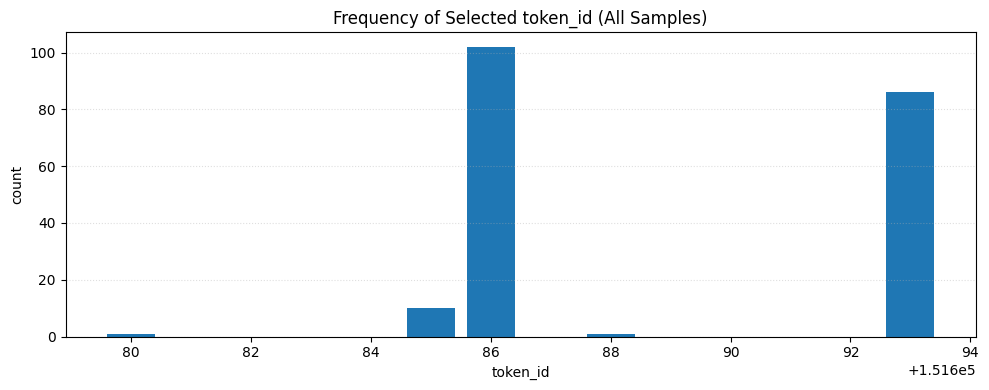

[1. 0. 0. 0.]


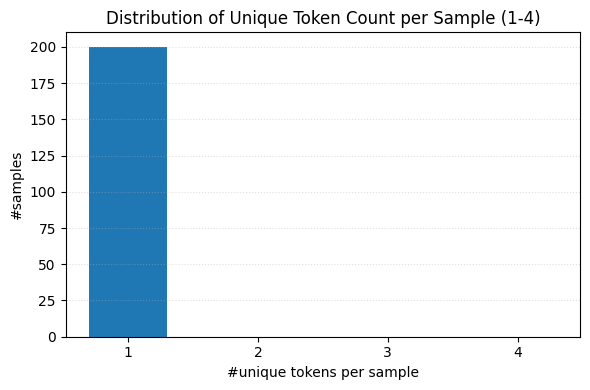

In-memory variables: all_selected_token_ids, per_sample_unique_counts


In [15]:
from typing import List

import numpy as np
import torch
import matplotlib.pyplot as plt

all_selected_token_ids: List[int] = []
per_sample_unique_counts: List[int] = []

# 使用同一个 DataLoader 迭代器避免每次都从第一个批次开始
iterator = iter(val_data)
num_iters = 200

for i in range(num_iters):
    try:
        data = next(iterator)
    except StopIteration:
        # 若耗尽，则重新创建迭代器
        iterator = iter(val_data)
        data = next(iterator)

    labels: torch.Tensor = data["labels"]
    if not isinstance(labels, torch.Tensor):
        continue

    # 选取有效 token（过滤 ignore_index = -100）
    valid_mask = labels != -100
    selected = labels[valid_mask]
    # print(selected)
    # print(labels)
    # break
    # 累积所有被选中的 token_id
    if selected.numel() > 0:
        all_selected_token_ids.extend(selected.cpu().tolist())

    # 统计每个样本中出现的唯一 token 个数（应在 1~4）
    if labels.dim() == 1:
        sel = labels[labels != -100]
        if sel.numel() > 0:
            per_sample_unique_counts.append(int(torch.unique(sel).numel()))
    else:
        # 按样本（batch 维度）统计
        for b in range(labels.shape[0]):
            row = labels[b]
            sel_b = row[row != -100]
            if sel_b.numel() > 0:
                per_sample_unique_counts.append(int(torch.unique(sel_b).numel()))
print(all_selected_token_ids)
print(per_sample_unique_counts)
# 图 1：对所有选取的 token_id 绘制统计（频次）图（仅显示，不保存）
if len(all_selected_token_ids) > 0:
    token_ids, counts = np.unique(np.asarray(all_selected_token_ids, dtype=np.int64), return_counts=True)

    plt.figure(figsize=(10, 4))
    plt.bar(token_ids.astype(int), counts.astype(int), width=0.8)
    plt.xlabel("token_id")
    plt.ylabel("count")
    plt.title("Frequency of Selected token_id (All Samples)")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

# 图 2：绘制每个样本中出现了多少种 token 的分布（1~4）（仅显示，不保存）
if len(per_sample_unique_counts) > 0:
    counts_arr = np.asarray(per_sample_unique_counts, dtype=int)
    xs = np.array([1, 2, 3, 4], dtype=int)
    ys = np.array([(counts_arr == k).sum() for k in xs], dtype=int)
    print(ys/200)
    plt.figure(figsize=(6, 4))
    plt.bar(xs, ys, width=0.6)
    plt.xticks(xs)
    plt.xlabel("#unique tokens per sample")
    plt.ylabel("#samples")
    plt.title("Distribution of Unique Token Count per Sample (1-4)")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

print("In-memory variables: all_selected_token_ids, per_sample_unique_counts")

In [ ]:
for i in range(num_iters):
    try:
        data = next(iterator)
    except StopIteration:
        # 若耗尽，则重新创建迭代器
        iterator = iter(val_data)
        data = next(iterator)

    labels: torch.Tensor = data["labels"]

In [1]:
import os
import random
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, List

import draccus
import torch
import torch.nn as nn
import torch.distributed as dist
import tqdm
from accelerate import PartialState
from peft import LoraConfig, get_peft_model
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers.models.auto.processing_auto import processor_class_from_name
from prismatic.overwatch import initialize_overwatch
import wandb
from prismatic.vla import get_latent_vla_dataset_and_collator
from prismatic.models.vlas.latent_world_vla import LatentWorldVLA, LatentWorldVLAConfig
from prismatic.util.data_utils import PaddedCollatorForActionPrediction_LIBERO
from prismatic.vla.datasets import RLDSBatchTransformLIBERO
from prismatic.vla.datasets.rlds.utils.data_utils import save_dataset_statistics
from latent_action_model.core.lam_model import load_latent_action_model
from prismatic.models.load import load_InternVL, freeze_internvl
# Sane Defaults
os.environ["TOKENIZERS_PARALLELISM"] = "false"

overwatch = initialize_overwatch(__name__)

home_path = "/mnt/mnt/public/jlchen"
@dataclass
class FinetuneConfig:
    # fmt: off
    # Base VLM & LAM
    model_id: str = home_path + "/code/UniVLA/vla_scripts/vla_log/1006_134451+InternVL3_5-1B-Instruct-HF+lam+n8+b24+x42--run_01--image_aug/checkpoints/checkpoint-4000"
    hf_cache_dir: Optional[str] = None
    lam_path: str = home_path + "/code/UniVLA/latent_action_model/logs/nsvq_ddp/version_0/checkpoints/epoch=1.ckpt"
    vision_model_id: str = home_path + "/weights/vjepa2-vitl-fpc64-256"
    # Dataset
    data_root_dir: Path = Path(home_path + "/datasets")
    data_mix: str = "libero"
    image_resolution: int = 448
    shuffle_buffer_size: int = 2000
    image_aug: bool = False

    # Run & IO
    run_root_dir: Path = Path(__file__).resolve().parent / "latent_world_vla_log"
    # adapter_tmp_dir: Path = Path("adapter-tmp")
    # save_latest_checkpoint_only: bool = True

    # Optimization
    batch_size: int = 2
    max_steps: int = 200000
    save_steps: int = 30000
    eval_steps: int = 1000
    eval_batches: int = 100
    learning_rate: float = 1e-5
    grad_accumulation_steps: int = 16
    gradient_clip: float = 1.0
    weight_decay: float = 1e-4
    vlm_loss_weight: float = 1.0

    # Seeding & dtype
    seed: int = 42

    # LAM/codebook
    codebook_size: int = 16

    # Freezing policy (applies to InternVL)
    freeze_vision_backbone: bool = True
    freeze_projector: bool = True
    freeze_llm_backbone: bool = True
    freeze_last_llm_layer: bool = True

    # LoRA (optional)
    use_lora: bool = False
    lora_rank: int = 32
    lora_dropout: float = 0.05
    lora_alpha: int = 32
    lora_target_modules: List[str] = None  # if None, use a sensible default
    # 是否在保存时同时导出 LoRA 适配器（便于后处理融合）
    save_lora_adapter: bool = True

    # Tracking
    wandb_project: str = "finetune-LIBERO"
    wandb_entity: str = "test-project"
    run_id_note: Optional[str] = None

cfg=FinetuneConfig

print(f"Fine-tuning LatentWorldVLA on `{cfg.data_mix}` with base `{cfg.model_id}`")

# [Validate] Ensure GPU Available & Set Device / Distributed Context
assert torch.cuda.is_available(), "Fine-tuning assumes at least one GPU is available!"
distributed_state = PartialState()
torch.cuda.set_device(device_id := distributed_state.local_process_index)
torch.cuda.empty_cache()

# Seeding
torch.manual_seed(cfg.seed + device_id)
torch.cuda.manual_seed_all(cfg.seed + device_id)
random.seed(cfg.seed + device_id)

# Configure Unique Experiment ID & Log Directory
exp_id = (
    f"{cfg.model_id.split('/')[-1]}+{cfg.data_mix}"
    f"+lr-{cfg.learning_rate}"
)
if cfg.use_lora:
    exp_id += f"+lora-r{cfg.lora_rank}+dropout-{cfg.lora_dropout}"
if cfg.run_id_note is not None:
    exp_id += f"--{cfg.run_id_note}"
if cfg.image_aug:
    exp_id += "--image_aug"

# Start =>> Build Directories (hierarchical)
run_dir = cfg.run_root_dir / exp_id
ckpt_root = run_dir / "checkpoints"
log_dir = run_dir / "logs"
os.makedirs(ckpt_root, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Load InternVL model & tokenizer
overwatch.info(f"🔄 加载基础 InternVL `{cfg.model_id}`（HF from_pretrained）")
vlm, processor = load_InternVL(cfg.model_id, cfg.hf_cache_dir, dtype=torch.bfloat16)
tokenizer = processor.tokenizer

# Extend tokenizer with latent action special tokens and resize embeddings
overwatch.info("🔧 扩充 LLM 词表以注入动作离散 token")
special_tokens_dict = {'additional_special_tokens': [f'<ACT_{i}>' for i in range(cfg.codebook_size)]}
try:
    num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)  # type: ignore[attr-defined]
except Exception:
    num_added_toks = 0
if num_added_toks > 0 and hasattr(vlm, 'resize_token_embeddings'):
    vlm.resize_token_embeddings(len(tokenizer))

# Freeze InternVL as configured
freeze_internvl(vlm, cfg.freeze_vision_backbone, cfg.freeze_projector, cfg.freeze_llm_backbone, cfg.freeze_last_llm_layer)

# Optional LoRA: attach to language_model submodules
if cfg.use_lora:
    target_modules = cfg.lora_target_modules or [
        'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'
    ]
    lora_cfg = LoraConfig(
        r=cfg.lora_rank,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=target_modules,
        bias="none",
        task_type="CAUSAL_LM",
    )
    # 将 LoRA 应用于整个 VLM（内部仅会匹配 target_modules）
    vlm = get_peft_model(vlm, lora_cfg)

# Load LAM
overwatch.info(
    f"🔄 加载 V-JEPA2 动作编码器与码本（ckpt=`{cfg.lam_path}`，K={cfg.codebook_size}）"
)
latent_action_model = load_latent_action_model(cfg.lam_path, vision_model_id=cfg.vision_model_id)
latent_action_model = latent_action_model.to(device_id).eval()

# Build LatentWorldVLA with config
model_cfg = LatentWorldVLAConfig()
# 根据 tokenizer 中 ACT_ token 的起始 id 校准 action_token_begin_id
act_tokens = [f"<ACT_{i}>" for i in range(cfg.codebook_size)]
act_ids = tokenizer.convert_tokens_to_ids(act_tokens)
if isinstance(act_ids, list) and len(act_ids) > 0 and min(act_ids) != -1:
    model_cfg.action_token_begin_id = min(act_ids)

overwatch.info("🔄 构建 LatentWorldVLA")
lwvla = LatentWorldVLA(
    lam=latent_action_model,
    model_cfg=model_cfg,
    vlm=vlm,
)


# 如果使用 LoRA，LatentWorldVLA 内部会对 VLM requires_grad_(False)，此处重新开启 LoRA 权重
if cfg.use_lora:
    for name, param in lwvla.vlm.named_parameters():
        if 'lora_' in name:
            param.requires_grad_(True)
    # 训练阶段启用 VLM 的 train 模式以激活 LoRA 分支（主体权重仍冻结）
    lwvla.vlm.train()

num_params = sum(p.numel() for p in lwvla.parameters())
num_trainable_params = sum(p.numel() for p in lwvla.parameters() if p.requires_grad)
overwatch.info(
    f"# LatentWorldVLA Parameters (in millions): {num_params / 10**6:.3f} Total, {num_trainable_params / 10**6:.3f} Trainable"
)

overwatch.info(
    f"🔄 构建 RLDS 数据集与 Collator(mixture=`{cfg.data_mix}`, image_res={cfg.image_resolution})"
)
train_dataset, val_dataset, tokenizer, collator = get_latent_vla_dataset_and_collator(
    cfg.data_root_dir,
    cfg.data_mix,
    latent_action_model,
    tokenizer=tokenizer,
    default_image_resolution=cfg.image_resolution,
    shuffle_buffer_size=cfg.shuffle_buffer_size,
    image_aug=cfg.image_aug,
    data_transform_fn=RLDSBatchTransformLIBERO,
    collator_fn=PaddedCollatorForActionPrediction_LIBERO,
)
# [Important] Save Dataset Statistics =>> used to de-normalize actions for inference!
if distributed_state.is_main_process:
    save_dataset_statistics(train_dataset.dataset_statistics, run_dir)

# DDP
lwvla = lwvla.to(device_id)
wrapped_model = DDP(lwvla, device_ids=[device_id], find_unused_parameters=True, gradient_as_bucket_view=True)

# Optimizer & LR scheduler
trainable_params = [param for param in wrapped_model.parameters() if param.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(cfg.max_steps * 0.8), gamma=0.1)

# DataLoader
dataloader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    sampler=None,
    collate_fn=collator,
    num_workers=0,  # RLDS 内部并行
)

2025-10-27 17:00:22.563321: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 17:00:22.605076: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-27 17:00:22.605096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-27 17:00:22.606141: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-27 17:00:22.612978: I tensorflow/core/platform/cpu_feature_guar

KeyboardInterrupt: 

In [46]:
from transformers import AutoVideoProcessor, AutoModel

hf_repo = "/mnt/mnt/public/jlchen/weights/vjepa2-vitl-fpc64-256"

model = AutoModel.from_pretrained(hf_repo,device_map="cuda")
processor = AutoVideoProcessor.from_pretrained(hf_repo)

In [51]:
import torch
video = torch.rand(5,3, 512, 512)  # 1帧示例
video_inputs = processor(video, return_tensors="pt").to(model.device)
print(video_inputs['pixel_values_videos'].shape)
# print(video_inputs.keys())
with torch.no_grad():
    video_embeddings = model.get_vision_features(**video_inputs)

print(video_embeddings.shape)
# print(video_embeddings.sum(-1))

torch.Size([1, 5, 3, 256, 256])
torch.Size([1, 512, 1024])


In [52]:
from transformers.processing_utils import VideosKwargs


video_1 = video[:,:5,:,:]
video_inputs_1 = processor(video_1, return_tensors="pt").to(model.device)
with torch.no_grad():
    video_embeddings_1 = model.get_vision_features(**video_inputs_1)

print(video_embeddings_1.mean())
print(video_embeddings.mean())

tensor(0.0573, device='cuda:0')
tensor(0.0573, device='cuda:0')


In [ ]:
import numpy as np
arr = np.linspace(0, 18, 5)
print(arr)
print(np.round(arr))
print(arr.astype(int))
# -> [0., 1., 1., 2., 2., 3.]


[ 0.    3.75  7.5  11.25 15.  ]
[ 0.  4.  8. 11. 15.]
[ 0  3  7 11 15]


In [7]:
import torch
from latent_action_model.core.utils.dpt_head import DPTHead
x = [torch.randn(2, 256, 1024), torch.randn(2, 256, 1024), torch.randn(2, 256, 1024), torch.randn(2, 256, 1024)]
head = DPTHead(in_channels=1024, grid_size=16, lvl=0)
y = head(x)
y.shape



torch.Size([2, 256, 32, 32])

In [1]:
import torch
from latent_action_model.core.utils.modules import build_action_block_causal_attention_mask
# 参数
T, H, W, add_tokens = 3, 2, 2, 2
N_T = add_tokens + H * W
N = T * N_T

# 自定义 block mask (True=可见)
custom_mask = build_action_block_causal_attention_mask(T, H, W, add_tokens)



# 可视化
print("Custom mask (对于F.sdpa，True=关注；对于其他的，True=屏蔽):")
print((custom_mask).int())

Custom mask (对于F.sdpa，True=关注；对于其他的，True=屏蔽):
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [2]:
from latent_action_model.core.utils.modules import build_modal_block_attention_mask, build_decoder_block_attention_mask
block_mask = build_modal_block_attention_mask(T, H, W, add_tokens=1, ar_query=True)
print(block_mask.int())
print((~block_mask | ~custom_mask).int())

tensor([[1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0

In [6]:
dec_mask=build_decoder_block_attention_mask(T, H, W, add_tokens=2,  is_causal=True)
print(dec_mask.int())


tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
        [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1